In [1]:
!pip install tensorflow kagglehub

In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.layers import *
from keras.models import *
from keras.regularizers import l2
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os, shutil
import warnings
warnings.filterwarnings('ignore')

In [3]:
import kagglehub
vegetable_image_dataset = kagglehub.dataset_download('misrakahmed/vegetable-image-dataset')

print('Data source import complete.')

100%|██████████| 534M/534M [00:06<00:00, 81.4MB/s] 

Extracting files...


Data source import complete.


In [6]:
vegetable_image_dataset

'/kaggle/input/vegetable-image-dataset'

In [4]:
vegetable_image_dataset=os.path.join(vegetable_image_dataset,'Vegetable Images')
vegetable_image_dataset

'/root/.cache/kagglehub/datasets/misrakahmed/vegetable-image-dataset/versions/1/Vegetable Images'

Visualising the image

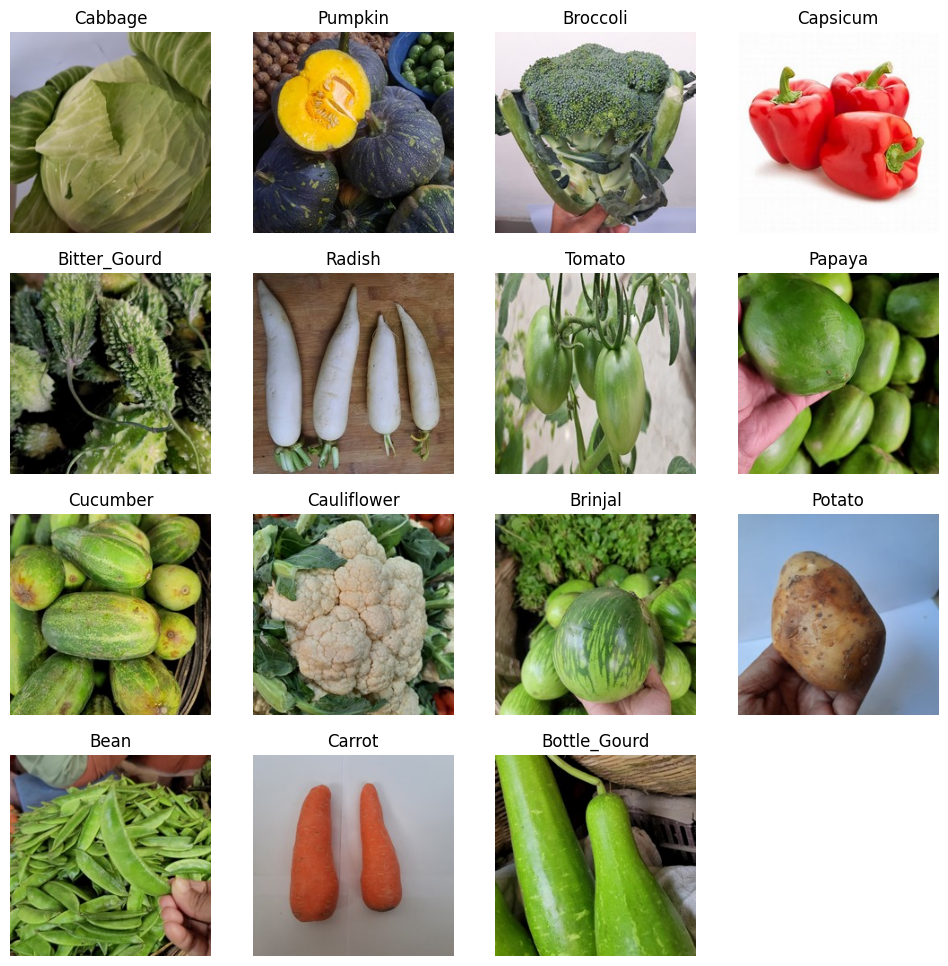

In [5]:
train_path = os.path.join(vegetable_image_dataset, "train")
validation_path = os.path.join(vegetable_image_dataset, "validation")
test_path = os.path.join(vegetable_image_dataset, "test")

image_categories = os.listdir(train_path)

def plot_images(image_categories):

    # Create a figure
    plt.figure(figsize=(12, 12))
    for i, cat in enumerate(image_categories):

        # Load images for the ith category
        image_path = train_path + '/' + cat
        images_in_folder = os.listdir(image_path)
        first_image_of_folder = images_in_folder[0]
        first_image_path = image_path + '/' + first_image_of_folder
        img = image.load_img(first_image_path)
        img_arr = image.img_to_array(img)/255.0


        # Create Subplot and plot the images
        plt.subplot(4, 4, i+1)
        plt.imshow(img_arr)
        plt.title(cat)
        plt.axis('off')

    plt.show()

# Call the function
plot_images(image_categories)

Preparing the Dataset

In [12]:
# Creating Image Data Generator for train, validation and test set

# 1. Train Set
train_gen = ImageDataGenerator(rescale = 1.0/255.0) # Normalise the data
train_image_generator = train_gen.flow_from_directory(
                                            train_path,
                                            target_size=(150, 150),
                                            batch_size=32,
                                            class_mode='categorical')

# 2. Validation Set
val_gen = ImageDataGenerator(rescale = 1.0/255.0) # Normalise the data
val_image_generator = val_gen.flow_from_directory(
                                            validation_path,
                                            target_size=(150, 150),
                                            batch_size=32,
                                            class_mode='categorical')

# 3. Test Set
test_gen = ImageDataGenerator(rescale = 1.0/255.0) # Normalise the data
test_image_generator = test_gen.flow_from_directory(
                                            test_path,
                                            target_size=(150, 150),
                                            batch_size=32,
                                            class_mode='categorical')

Found 15000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.


In [13]:
# Print the class encodings done by the generators
class_map = dict([(v, k) for k, v in train_image_generator.class_indices.items()])
print(class_map)

{0: 'Bean', 1: 'Bitter_Gourd', 2: 'Bottle_Gourd', 3: 'Brinjal', 4: 'Broccoli', 5: 'Cabbage', 6: 'Capsicum', 7: 'Carrot', 8: 'Cauliflower', 9: 'Cucumber', 10: 'Papaya', 11: 'Potato', 12: 'Pumpkin', 13: 'Radish', 14: 'Tomato'}


### ANN

In [ ]:
# Define the ANN model
ann_model = Sequential([
    Flatten(input_shape=(150, 150, 3)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(15, activation='softmax')
])

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    34,560,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,726,671 (132.47 MB)

 Trainable params: 34,726,671 (132.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
ann_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
hist = ann_model.fit(train_image_generator,
                 epochs=10,
                 verbose=2,
                 validation_data=val_image_generator,
                 steps_per_epoch = 15000//32,  #15000 samples in training data and 32 batch size
                 validation_steps = 3000//32, ) #3000 samples in validation data and 32 batch size

Epoch 1/10
468/468 - 18s - 38ms/step - accuracy: 0.0627 - loss: 2.7083 - val_accuracy: 0.0672 - val_loss: 2.7080
Epoch 2/10
468/468 - 3s - 6ms/step - accuracy: 0.0000e+00 - loss: 2.7087 - val_accuracy: 0.0669 - val_loss: 2.7081
Epoch 3/10
468/468 - 17s - 36ms/step - accuracy: 0.0621 - loss: 2.7083 - val_accuracy: 0.0672 - val_loss: 2.7080
Epoch 4/10
468/468 - 3s - 7ms/step - accuracy: 0.0625 - loss: 2.7083 - val_accuracy: 0.0669 - val_loss: 2.7081
Epoch 5/10
468/468 - 17s - 36ms/step - accuracy: 0.0641 - loss: 2.7083 - val_accuracy: 0.0669 - val_loss: 2.7081
Epoch 6/10
468/468 - 3s - 6ms/step - accuracy: 0.0312 - loss: 2.7091 - val_accuracy: 0.0669 - val_loss: 2.7081
Epoch 7/10
468/468 - 17s - 37ms/step - accuracy: 0.0621 - loss: 2.7083 - val_accuracy: 0.0662 - val_loss: 2.7081
Epoch 8/10
468/468 - 3s - 6ms/step - accuracy: 0.0625 - loss: 2.7083 - val_accuracy: 0.0665 - val_loss: 2.7081
Epoch 9/10
468/468 - 18s - 38ms/step - accuracy: 0.0633 - loss: 2.7083 - val_accuracy: 0.0665 - val_

In [ ]:
test_loss,test_acc = ann_model.evaluate(test_image_generator)
print('Test accuracy:', test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.0626 - loss: 2.7081
Test accuracy: 0.06666667014360428


### CNN

In [ ]:

cnn_model = Sequential()

cnn_model.add(Conv2D(filters=32, kernel_size=3, strides=1, padding='same', activation='relu', input_shape=[150, 150, 3]))
cnn_model.add(MaxPooling2D(2))
cnn_model.add(Conv2D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu'))
cnn_model.add(MaxPooling2D(2))

cnn_model.add(Flatten())

cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.25))
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dense(15, activation='softmax'))

cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 87616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │    11,214,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,252,815 (42.93 MB)

 Trainable params: 11,252,815 (42.93 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile and fit the model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
hist_cnn = cnn_model.fit(train_image_generator,
                 epochs=20,
                 verbose=2,
                 validation_data=val_image_generator,
                 steps_per_epoch = 15000//32,
                 validation_steps = 3000//32, )

Epoch 1/20
468/468 - 29s - 61ms/step - accuracy: 0.5691 - loss: 1.3114 - val_accuracy: 0.8138 - val_loss: 0.5893
Epoch 2/20
468/468 - 3s - 6ms/step - accuracy: 0.7500 - loss: 0.7226 - val_accuracy: 0.8222 - val_loss: 0.5695
Epoch 3/20
468/468 - 20s - 44ms/step - accuracy: 0.8023 - loss: 0.6183 - val_accuracy: 0.8676 - val_loss: 0.4216
Epoch 4/20
468/468 - 3s - 6ms/step - accuracy: 0.7500 - loss: 0.5742 - val_accuracy: 0.8649 - val_loss: 0.4210
Epoch 5/20
468/468 - 19s - 40ms/step - accuracy: 0.8828 - loss: 0.3721 - val_accuracy: 0.9123 - val_loss: 0.2835
Epoch 6/20
468/468 - 3s - 6ms/step - accuracy: 0.8750 - loss: 0.3238 - val_accuracy: 0.9089 - val_loss: 0.2913
Epoch 7/20
468/468 - 18s - 39ms/step - accuracy: 0.9162 - loss: 0.2588 - val_accuracy: 0.9318 - val_loss: 0.2425
Epoch 8/20
468/468 - 3s - 7ms/step - accuracy: 0.9688 - loss: 0.1287 - val_accuracy: 0.9298 - val_loss: 0.2468
Epoch 9/20
468/468 - 19s - 41ms/step - accuracy: 0.9338 - loss: 0.1929 - val_accuracy: 0.9251 - val_loss

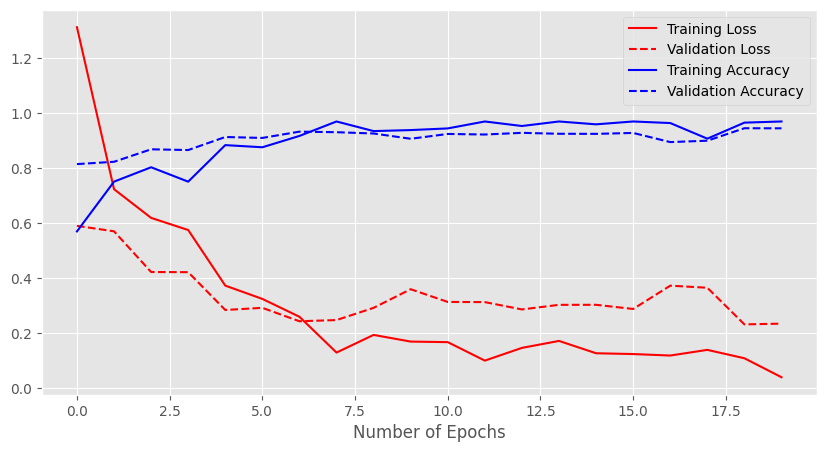

In [ ]:
# Plot the error and accuracy
h = hist_cnn.history
plt.style.use('ggplot')
plt.figure(figsize=(10, 5))
plt.plot(h['loss'], c='red', label='Training Loss')
plt.plot(h['val_loss'], c='red', linestyle='--', label='Validation Loss')
plt.plot(h['accuracy'], c='blue', label='Training Accuracy')
plt.plot(h['val_accuracy'], c='blue', linestyle='--', label='Validation Accuracy')
plt.xlabel("Number of Epochs")
plt.legend(loc='best')
plt.show()

In [ ]:
cnn_model.evaluate(test_image_generator)

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9405 - loss: 0.2760


[0.25446510314941406, 0.9443333148956299]

Testing the model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


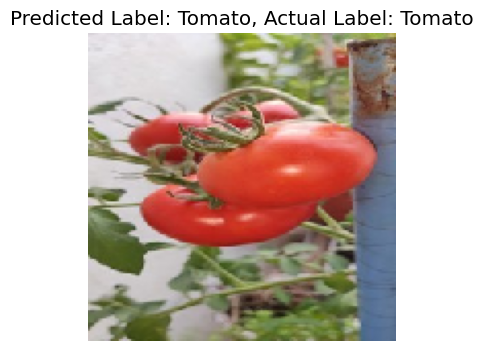

In [ ]:
# Testing the Model
test_image_path = os.path.join(test_path,'Tomato/1011.jpg')

def generate_predictions(test_image_path, actual_label):

    # 1. Load and preprocess the image
    test_img = image.load_img(test_image_path, target_size=(150, 150))
    test_img_arr = image.img_to_array(test_img)/255.0
    test_img_input = test_img_arr.reshape((1, test_img_arr.shape[0], test_img_arr.shape[1], test_img_arr.shape[2]))

    # 2. Make Predictions
    predicted_label = np.argmax(cnn_model.predict(test_img_input))
    predicted_vegetable = class_map[predicted_label]
    plt.figure(figsize=(4, 4))
    plt.imshow(test_img_arr)
    plt.title("Predicted Label: {}, Actual Label: {}".format(predicted_vegetable, actual_label))
    plt.grid()
    plt.axis('off')
    plt.show()

# call the function
generate_predictions(test_image_path, actual_label='Tomato')

### CNN with regularizer

In [ ]:
cnn_model2 = Sequential()

cnn_model2.add(Conv2D(filters=32, kernel_size=3, strides=1, padding='same', activation='relu', input_shape=[150, 150, 3],kernel_regularizer=l2(0.01)))
cnn_model2.add(MaxPooling2D(2))
cnn_model2.add(Conv2D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu', kernel_regularizer=l2(0.01)))
cnn_model2.add(MaxPooling2D(2))

cnn_model2.add(Flatten())

cnn_model2.add(Dense(128, activation='relu'))
cnn_model2.add(Dropout(0.25))
cnn_model2.add(Dense(128, activation='relu'))
cnn_model2.add(Dense(15, activation='softmax'))

cnn_model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 87616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,214,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,252,815 (42.93 MB)

 Trainable params: 11,252,815 (42.93 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile and fit the model
cnn_model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
hist_cnn2 = cnn_model2.fit(train_image_generator,
                 epochs=20,
                 verbose=2,
                 validation_data=val_image_generator,
                 steps_per_epoch = 15000//32,
                 validation_steps = 3000//32, )

Epoch 1/20
468/468 - 32s - 69ms/step - accuracy: 0.5279 - loss: 1.6630 - val_accuracy: 0.7527 - val_loss: 0.9241
Epoch 2/20
468/468 - 3s - 6ms/step - accuracy: 0.7500 - loss: 1.0766 - val_accuracy: 0.7591 - val_loss: 0.9012
Epoch 3/20
468/468 - 19s - 42ms/step - accuracy: 0.7686 - loss: 0.8369 - val_accuracy: 0.8602 - val_loss: 0.5825
Epoch 4/20
468/468 - 3s - 6ms/step - accuracy: 0.9062 - loss: 0.4473 - val_accuracy: 0.8542 - val_loss: 0.5976
Epoch 5/20
468/468 - 20s - 42ms/step - accuracy: 0.8479 - loss: 0.5775 - val_accuracy: 0.8975 - val_loss: 0.4364
Epoch 6/20
468/468 - 3s - 6ms/step - accuracy: 0.7188 - loss: 0.8182 - val_accuracy: 0.9029 - val_loss: 0.4282
Epoch 7/20
468/468 - 21s - 46ms/step - accuracy: 0.8847 - loss: 0.4544 - val_accuracy: 0.9089 - val_loss: 0.4078
Epoch 8/20
468/468 - 3s - 6ms/step - accuracy: 0.9375 - loss: 0.2688 - val_accuracy: 0.9079 - val_loss: 0.3950
Epoch 9/20
468/468 - 19s - 41ms/step - accuracy: 0.9089 - loss: 0.3784 - val_accuracy: 0.9241 - val_loss

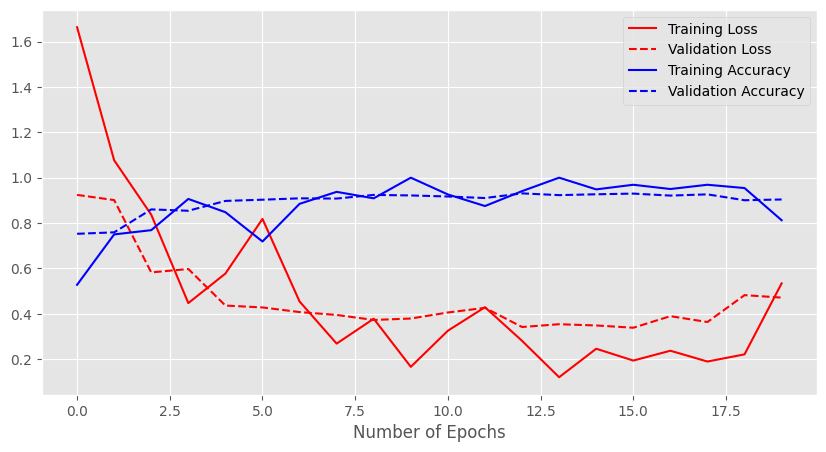

In [ ]:
# Plot the error and accuracy
h = hist_cnn2.history
plt.style.use('ggplot')
plt.figure(figsize=(10, 5))
plt.plot(h['loss'], c='red', label='Training Loss')
plt.plot(h['val_loss'], c='red', linestyle='--', label='Validation Loss')
plt.plot(h['accuracy'], c='blue', label='Training Accuracy')
plt.plot(h['val_accuracy'], c='blue', linestyle='--', label='Validation Accuracy')
plt.xlabel("Number of Epochs")
plt.legend(loc='best')
plt.show()

In [ ]:
cnn_model2.evaluate(test_image_generator)

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9149 - loss: 0.4474


[0.4354824125766754, 0.9120000004768372]

### Transfer Learning

#### MobileNet

Feature Extraction

In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_input_mobilenet

In [14]:
# Creating Image Data Generator for train, validation and test set

# 1. Train Set
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input_mobilenet) # Normalise the data
train_image_generator_mobilenet = train_gen.flow_from_directory(
                                            train_path,
                                            target_size=(150, 150),
                                            batch_size=32,
                                            class_mode='categorical')

# 2. Validation Set
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input_mobilenet) # Normalise the data
val_image_generator_mobilenet = val_gen.flow_from_directory(
                                            validation_path,
                                            target_size=(150, 150),
                                            batch_size=32,
                                            class_mode='categorical')

# 3. Test Set
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input_mobilenet) # Normalise the data
test_image_generator_mobilenet = test_gen.flow_from_directory(
                                            test_path,
                                            target_size=(150, 150),
                                            batch_size=32,
                                            class_mode='categorical')

Found 15000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.


In [15]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)
base_model.trainable = False  # Freeze base model

inputs = Input(shape=(150,150,3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(train_image_generator_mobilenet.num_classes, activation='softmax')(x)
mobilenet_model = Model(inputs, outputs)

mobilenet_model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

mobilenet_model.fit(train_image_generator_mobilenet,
                    validation_data=val_image_generator_mobilenet,
                    epochs=10)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 58s 106ms/step - accuracy: 0.8124 - loss: 0.6350 - val_accuracy: 0.9893 - val_loss: 0.0343
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.9778 - loss: 0.0773 - val_accuracy: 0.9950 - val_loss: 0.0139
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.9833 - loss: 0.0526 - val_accuracy: 0.9947 - val_loss: 0.0168
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 58ms/step - accuracy: 0.9889 - loss: 0.0361 - val_accuracy: 0.9983 - val_loss: 0.0064
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.9925 - loss: 0.0263 - val_accuracy: 0.9943 - val_loss: 0.0145
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.9883 - loss: 0.0357 - val_accuracy: 0.9980 - val_loss: 0.0059
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.9910 - loss: 0.0257 - val_accuracy: 0.9987 - val_loss: 0.0042
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - accuracy: 0.9905 - loss: 0.0257 -

In [16]:
test_loss,test_acc = mobilenet_model.evaluate(test_image_generator_mobilenet)
print('Test accuracy:', test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 162ms/step - accuracy: 0.9966 - loss: 0.0072
Test accuracy: 0.9963333606719971


Fine Tuning

In [19]:
base_model.trainable = True
for layer in base_model.layers[:-60]:
    layer.trainable = False

mobilenet_model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])
mobilenet_model.fit(train_image_generator_mobilenet, validation_data=val_image_generator_mobilenet, epochs=10)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.9917 - loss: 0.0480 - val_accuracy: 0.9747 - val_loss: 0.2704
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - accuracy: 0.9932 - loss: 0.0324 - val_accuracy: 0.9837 - val_loss: 0.1322
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - accuracy: 0.9927 - loss: 0.0444 - val_accuracy: 0.9903 - val_loss: 0.0885
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - accuracy: 0.9957 - loss: 0.0221 - val_accuracy: 0.9977 - val_loss: 0.0201
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.9985 - loss: 0.0071 - val_accuracy: 0.9973 - val_loss: 0.0200
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - accuracy: 0.9962 - loss: 0.0190 - val_accuracy: 0.9960 - val_loss: 0.0172
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.9947 - loss: 0.0269 - val_accuracy: 0.9933 - val_loss: 0.0956
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.9901 - loss: 0.0618 - 

In [21]:
test_loss,test_acc = mobilenet_model.evaluate(test_image_generator_mobilenet)
print('Test accuracy:', test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.9981 - loss: 0.0134
Test accuracy: 0.9980000257492065


#### VGGNet19

Feature Extraction

In [39]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input as preprocess_input_vgg

In [40]:
# Creating Image Data Generator for train, validation and test set

# 1. Train Set
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input_vgg) # Normalise the data
train_image_generator_vgg = train_gen.flow_from_directory(
                                            train_path,
                                            target_size=(150, 150),
                                            batch_size=32,
                                            class_mode='categorical')

# 2. Validation Set
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input_vgg) # Normalise the data
val_image_generator_vgg = val_gen.flow_from_directory(
                                            validation_path,
                                            target_size=(150, 150),
                                            batch_size=32,
                                            class_mode='categorical')

# 3. Test Set
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input_vgg) # Normalise the data
test_image_generator_vgg = test_gen.flow_from_directory(
                                            test_path,
                                            target_size=(150, 150),
                                            batch_size=32,
                                            class_mode='categorical')

Found 15000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.


In [30]:
# --- Base Model ---
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(150,150,3))
base_model.trainable = False

# --- Model Creation ---
inputs = Input(shape=(150,150,3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(train_image_generator_vgg.num_classes, activation='softmax')(x)
vgg19_model = Model(inputs, outputs)

# --- Compile & Train ---
vgg19_model.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])
vgg19_model.fit(train_image_generator_vgg, validation_data=val_image_generator_vgg, epochs=10)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 97s 182ms/step - accuracy: 0.7314 - loss: 2.6988 - val_accuracy: 0.9857 - val_loss: 0.0460
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 160ms/step - accuracy: 0.9631 - loss: 0.1240 - val_accuracy: 0.9907 - val_loss: 0.0311
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 159ms/step - accuracy: 0.9810 - loss: 0.0597 - val_accuracy: 0.9937 - val_loss: 0.0266
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 74s 158ms/step - accuracy: 0.9831 - loss: 0.0524 - val_accuracy: 0.9937 - val_loss: 0.0179
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 74s 158ms/step - accuracy: 0.9840 - loss: 0.0532 - val_accuracy: 0.9957 - val_loss: 0.0189
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 74s 158ms/step - accuracy: 0.9858 - loss: 0.0477 - val_accuracy: 0.9937 - val_loss: 0.0197
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 74s 158ms/step - accuracy: 0.9886 - loss: 0.0459 - val_accuracy: 0.9933 - val_loss: 0.0336
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 74s 159ms/step - accuracy: 0.9861 - loss: 0

In [31]:
test_loss,test_acc = vgg19_model.evaluate(test_image_generator_vgg)
print('Test accuracy:', test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step - accuracy: 0.9951 - loss: 0.0236
Test accuracy: 0.9933333396911621


Fine Tuning

In [37]:
from tensorflow.keras.optimizers import Adam

In [42]:
base_model.trainable = True
for layer in base_model.layers[:-5]:
    layer.trainable = False

vgg19_model.compile(optimizer=Adam(learning_rate=1e-5),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

vgg19_model.fit(train_image_generator_vgg, validation_data=val_image_generator_vgg, epochs=5)

vgg19_model.evaluate(test_image_generator_vgg)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 200ms/step - accuracy: 0.9901 - loss: 0.0339 - val_accuracy: 0.9957 - val_loss: 0.0164
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 89s 190ms/step - accuracy: 0.9941 - loss: 0.0248 - val_accuracy: 0.9970 - val_loss: 0.0132
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 90s 192ms/step - accuracy: 0.9967 - loss: 0.0111 - val_accuracy: 0.9987 - val_loss: 0.0070
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 90s 191ms/step - accuracy: 0.9965 - loss: 0.0141 - val_accuracy: 0.9983 - val_loss: 0.0048
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 90s 191ms/step - accuracy: 0.9978 - loss: 0.0076 - val_accuracy: 0.9990 - val_loss: 0.0076
94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step - accuracy: 0.9960 - loss: 0.0160


[0.014580619521439075, 0.996666669845581]

In [43]:
test_loss,test_acc = vgg19_model.evaluate(test_image_generator_vgg)
print('Test accuracy:', test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.9963 - loss: 0.0147
Test accuracy: 0.996666669845581


#### EffecientNetB0

Feature Extraction

In [6]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_input_eff

In [7]:
# Creating Image Data Generator for train, validation and test set

# 1. Train Set
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input_eff) # Normalise the data
train_image_generator_eff = train_gen.flow_from_directory(
                                            train_path,
                                            target_size=(150, 150),
                                            batch_size=32,
                                            class_mode='categorical')

# 2. Validation Set
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input_eff) # Normalise the data
val_image_generator_eff = val_gen.flow_from_directory(
                                            validation_path,
                                            target_size=(150, 150),
                                            batch_size=32,
                                            class_mode='categorical')

# 3. Test Set
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input_eff) # Normalise the data
test_image_generator_eff = test_gen.flow_from_directory(
                                            test_path,
                                            target_size=(150, 150),
                                            batch_size=32,
                                            class_mode='categorical')

Found 15000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.


In [8]:
# --- Base Model ---
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(150,150,3))
base_model.trainable = False

# --- Model Creation ---
inputs = Input(shape=(150,150,3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(train_image_generator_eff.num_classes, activation='softmax')(x)
eff_model = Model(inputs, outputs)

# --- Compile & Train ---
eff_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
eff_model.fit(train_image_generator_eff, validation_data=val_image_generator_eff, epochs=10)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 79s 107ms/step - accuracy: 0.9462 - loss: 0.2063 - val_accuracy: 0.9970 - val_loss: 0.0150
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.9933 - loss: 0.0276 - val_accuracy: 0.9977 - val_loss: 0.0099
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.9963 - loss: 0.0162 - val_accuracy: 0.9980 - val_loss: 0.0064
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.9959 - loss: 0.0145 - val_accuracy: 0.9973 - val_loss: 0.0060
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step - accuracy: 0.9973 - loss: 0.0114 - val_accuracy: 0.9987 - val_loss: 0.0042
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.9976 - loss: 0.0085 - val_accuracy: 0.9990 - val_loss: 0.0048
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step - accuracy: 0.9983 - loss: 0.0064 - val_accuracy: 0.9993 - val_loss: 0.0029
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━

In [26]:
test_loss,test_acc = eff_model.evaluate(test_image_generator_eff)
print('Test accuracy:', test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9983 - loss: 0.0040
Test accuracy: 0.9983333349227905


In [31]:
from sklearn.metrics import classification_report
import numpy as np

# Recreate test generator with shuffle=False
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input_eff)
test_image_generator_eff = test_gen.flow_from_directory(
    test_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_image_generator_eff.reset()
pred = eff_model.predict(test_image_generator_eff)

y_pred = np.argmax(pred, axis=1)
y_true = test_image_generator_eff.classes

print(classification_report(y_true, y_pred, target_names=list(test_image_generator_eff.class_indices.keys())))

Found 3000 images belonging to 15 classes.
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step
              precision    recall  f1-score   support

        Bean       1.00      1.00      1.00       200
Bitter_Gourd       1.00      0.99      1.00       200
Bottle_Gourd       1.00      1.00      1.00       200
     Brinjal       0.99      1.00      1.00       200
    Broccoli       1.00      1.00      1.00       200
     Cabbage       1.00      0.99      1.00       200
    Capsicum       1.00      1.00      1.00       200
      Carrot       1.00      1.00      1.00       200
 Cauliflower       1.00      1.00      1.00       200
    Cucumber       0.99      0.99      0.99       200
      Papaya       1.00      0.99      0.99       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       1.00      1.00      1.00       200
      Radish       1.00      1.00      1.00       200
      Tomato       1.00      1.00      1.00       200

    accuracy                           1.00      30

Fine Tuning

In [32]:
base_model.trainable = True
for layer in base_model.layers[:-60]:
    layer.trainable = False

eff_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
eff_model.fit(train_image_generator_eff, validation_data=val_image_generator_eff, epochs=5)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 108ms/step - accuracy: 0.9739 - loss: 0.1089 - val_accuracy: 0.9837 - val_loss: 0.0853
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.9851 - loss: 0.0652 - val_accuracy: 0.9933 - val_loss: 0.0326
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.9901 - loss: 0.0452 - val_accuracy: 0.9987 - val_loss: 0.0035
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.9935 - loss: 0.0288 - val_accuracy: 0.9973 - val_loss: 0.0104
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - accuracy: 0.9958 - loss: 0.0147 - val_accuracy: 0.9993 - val_loss: 0.0016


In [33]:
test_loss,test_acc = eff_model.evaluate(test_image_generator_eff)
print('Test accuracy:', test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9993 - loss: 0.0032
Test accuracy: 0.9993333220481873


Classification Report

In [61]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [67]:
os.chdir('/content/drive/MyDrive/Colab Notebooks/Vegetable Image Detection')

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

pred = eff_model.predict(test_image_generator_eff)

y_pred = np.argmax(pred, axis=1)
y_true = test_image_generator_eff.classes

print(classification_report(y_true, y_pred, target_names=list(test_image_generator_eff.class_indices.keys())))

94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step
              precision    recall  f1-score   support

        Bean       1.00      1.00      1.00       200
Bitter_Gourd       1.00      0.99      1.00       200
Bottle_Gourd       1.00      1.00      1.00       200
     Brinjal       1.00      1.00      1.00       200
    Broccoli       1.00      1.00      1.00       200
     Cabbage       1.00      0.99      1.00       200
    Capsicum       1.00      1.00      1.00       200
      Carrot       1.00      1.00      1.00       200
 Cauliflower       1.00      1.00      1.00       200
    Cucumber       1.00      1.00      1.00       200
      Papaya       1.00      1.00      1.00       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       1.00      1.00      1.00       200
      Radish       1.00      1.00      1.00       200
      Tomato       1.00      1.00      1.00       200

    accuracy                           1.00      3000
   macro avg       1.00      1.00     

In [ ]:
import pandas as pd
# Get report as a dictionary
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=list(test_image_generator_eff.class_indices.keys()),
    output_dict=True
)

# Convert to DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Save as CSV
report_df.to_csv("metrics/classification_report.csv", index=True)

Confusion Matrix

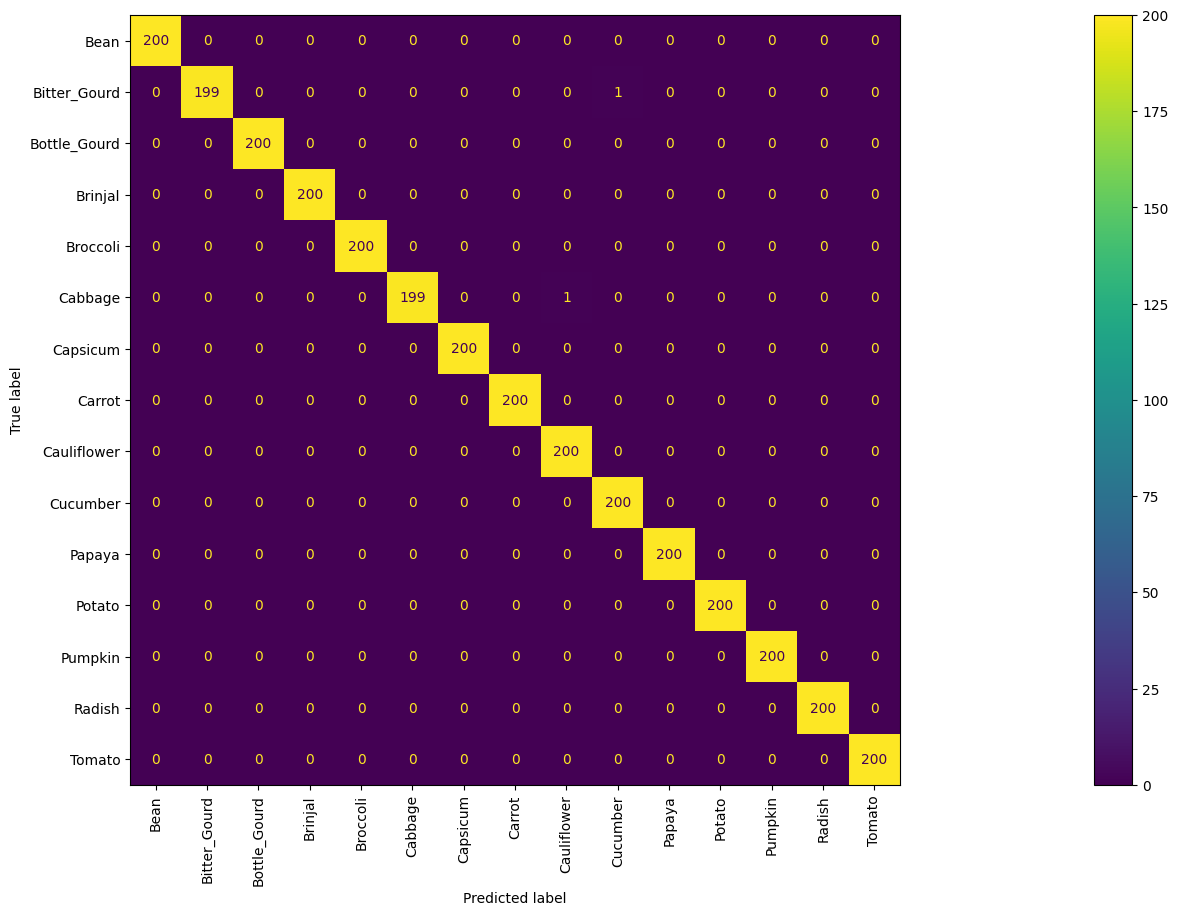

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=list(test_image_generator_eff.class_indices.keys()))
ax = plt.subplots(figsize=(50, 10))[1]
disp.plot(ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.show()

Saving the Model

In [71]:
# Save the full model
eff_model.save("eff_model.keras")

In [74]:
import json

with open("class_indices.json", "w") as f:
    json.dump(test_image_generator_eff.class_indices, f)